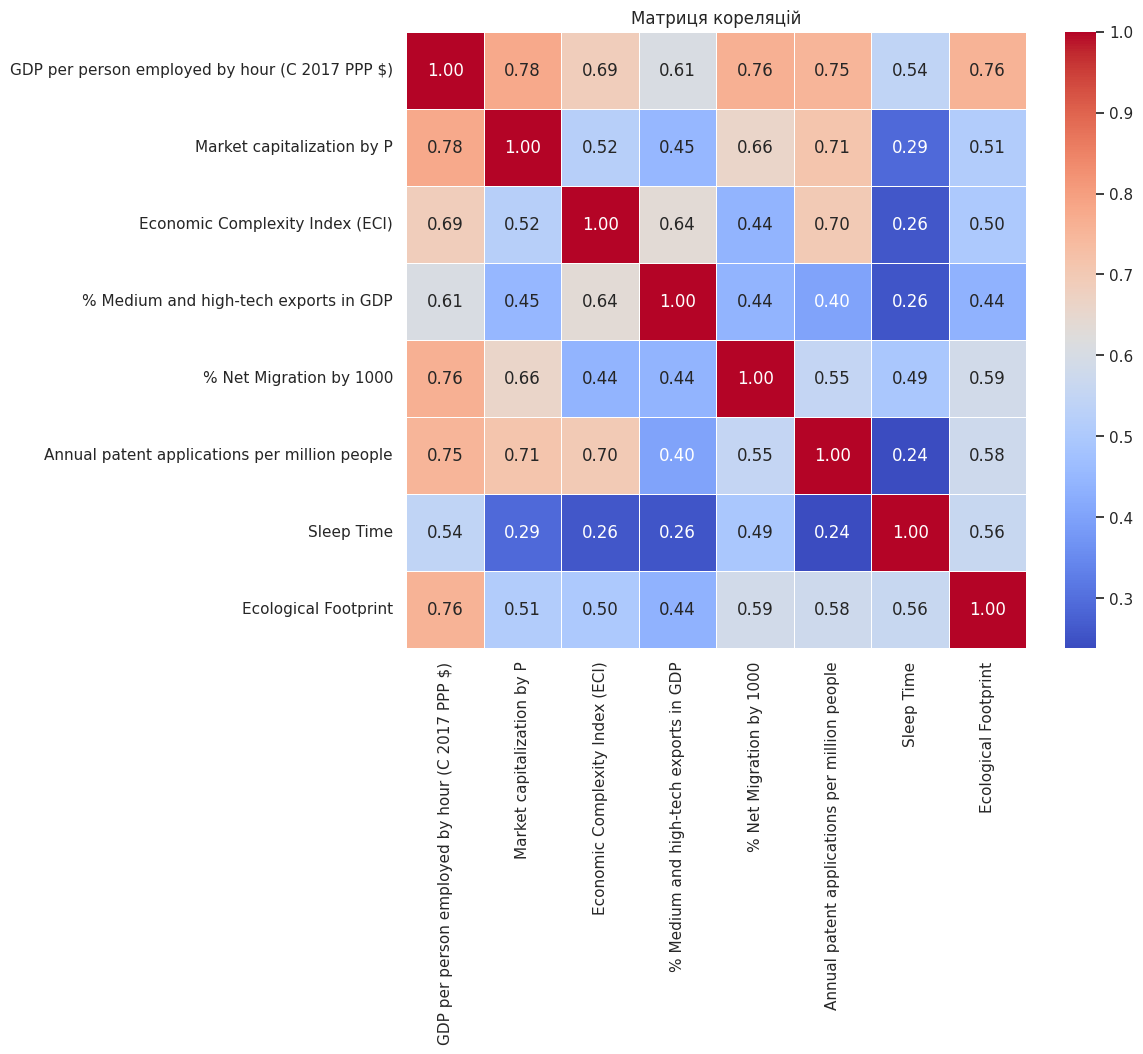

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Завантаження даних з файлу Excel
data = pd.read_excel("Вих Дані.xlsx")

# Видалення стовпця "Country"
data_numeric = data.drop(columns=["Country"])

# Побудова матриці кореляцій
correlation_matrix = data_numeric.corr()

# Встановлення стилю для візуалізації
sns.set(style="white")

# Побудова теплокарти матриці кореляцій
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матриця кореляцій')
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel('Вих Дані.xlsx')
df = df.drop(columns='Country')


X = df.drop(columns='GDP per person employed by hour (C 2017 PPP $)')
X = sm.add_constant(X)
y = df['GDP per person employed by hour (C 2017 PPP $)']

model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                                          OLS Regression Results                                          
Dep. Variable:     GDP per person employed by hour (C 2017 PPP $)   R-squared:                       0.879
Model:                                                        OLS   Adj. R-squared:                  0.867
Method:                                             Least Squares   F-statistic:                     72.54
Date:                                            Tue, 23 Apr 2024   Prob (F-statistic):           1.49e-29
Time:                                                    21:39:21   Log-Likelihood:                -275.73
No. Observations:                                              78   AIC:                             567.5
Df Residuals:                                                  70   BIC:                             586.3
Df Model:                                                       7                                         
Covariance Type:                     

In [ ]:
from scipy.stats import f

# Отримуємо значення F-статистики та кількість ступенів свободи моделі
f_statistic = result.fvalue
dof_model = X.shape[1] - 1

# Кількість ступенів свободи для залишкової суми квадратів
dof_resid = result.df_resid

# Обчислюємо ймовірність, що отримане значення F-статистики може бути досягнуте випадково
p_value = f.sf(f_statistic, dof_model, dof_resid)

# Виводимо результат
print("F-статистика:", f_statistic)
print("Кількість ступенів свободи моделі:", dof_model)
print("Кількість ступенів свободи залишкової суми квадратів:", dof_resid)
print("Ймовірність:", p_value)

F-статистика: 72.5351335339502
Кількість ступенів свободи моделі: 7
Кількість ступенів свободи залишкової суми квадратів: 70.0
Ймовірність: 1.489245456371968e-29


In [ ]:
from scipy.stats import f

# Задаємо рівень значущості alpha
alpha = 0.05

# Визначаємо критичне значення F-статистики для вказаного рівня значущості та ступенів свободи
critical_value = f.ppf(1 - alpha, dof_model, dof_resid)

critical_value

2.1434780407053386

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # Створюємо датафрейм для зберігання результатів
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Застосовуємо функцію до незалежних змінних X
vif_results = calculate_vif(X)

# Виводимо результати
print(vif_results)

                                         Feature         VIF
0                                          const  566.036526
1                     Market capitalization by P    2.631101
2                Economic Complexity Index (ECI)    2.827417
3          % Medium and high-tech exports in GDP    1.927314
4                        % Net Migration by 1000    2.313416
5  Annual patent applications per million people    3.369076
6                                     Sleep Time    1.642478
7                           Ecological Footprint    2.255545


In [ ]:
import statsmodels.stats.api as sms

# Перевірка гетероскедастичності за допомогою тесту Бройша-Пагана
breush_pagan_test = sms.het_breuschpagan(result.resid, result.model.exog)
print("Breusch-Pagan test p-value:", breush_pagan_test[1])

Breusch-Pagan test p-value: 0.09346397084688292


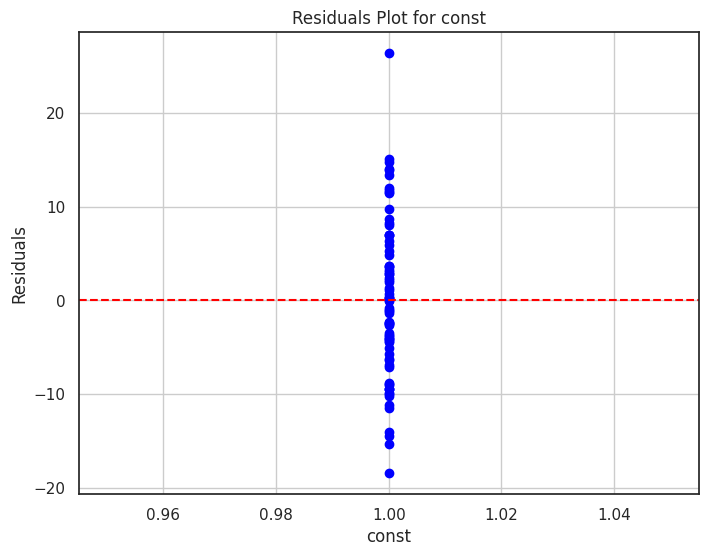

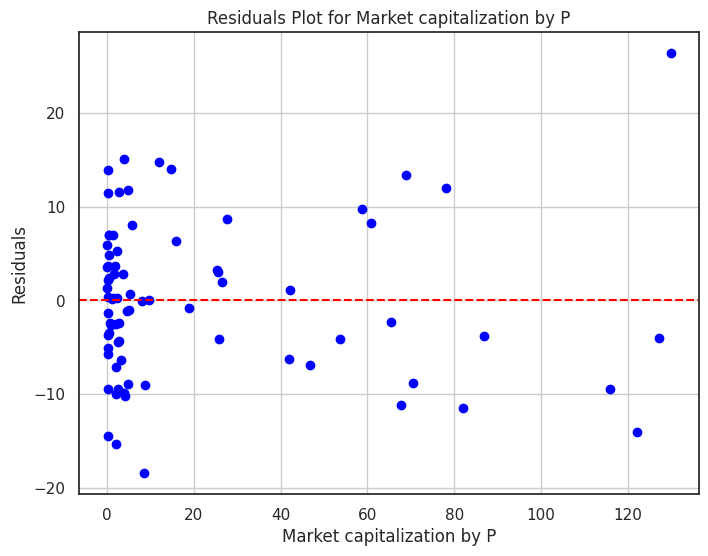

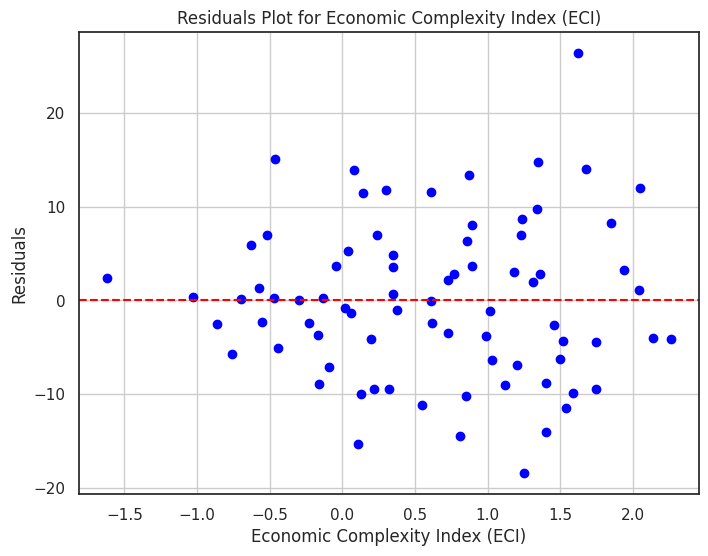

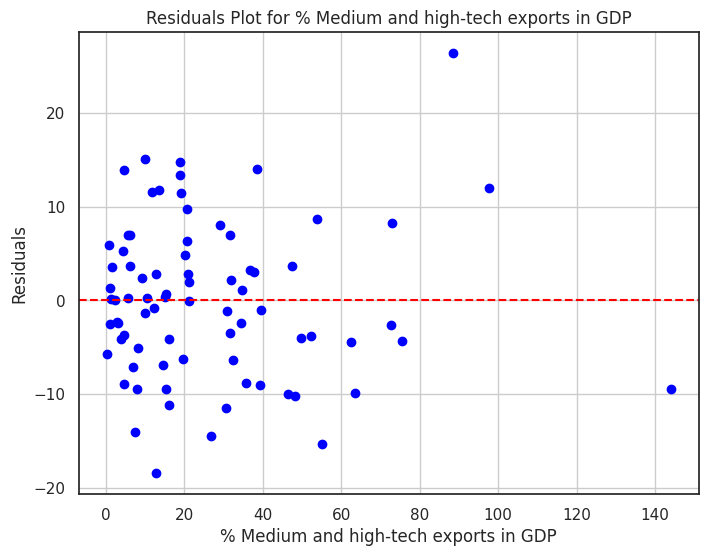

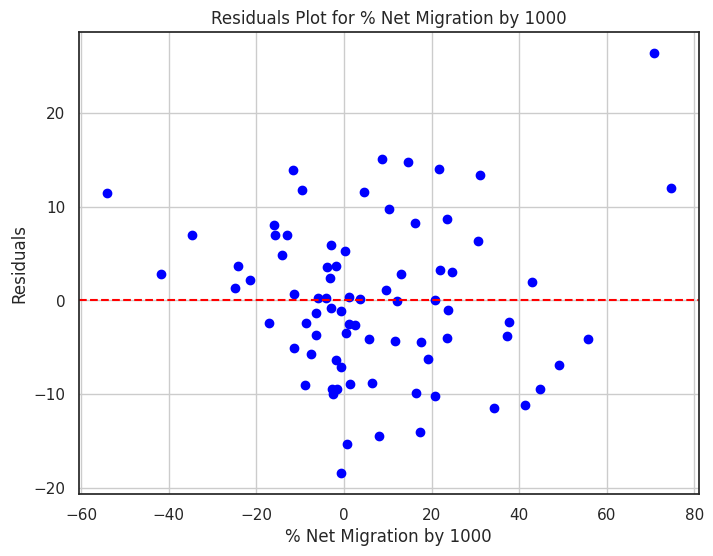

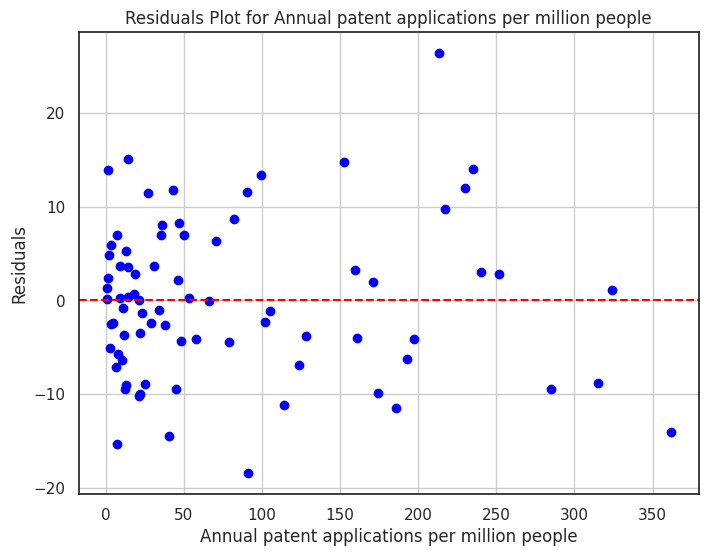

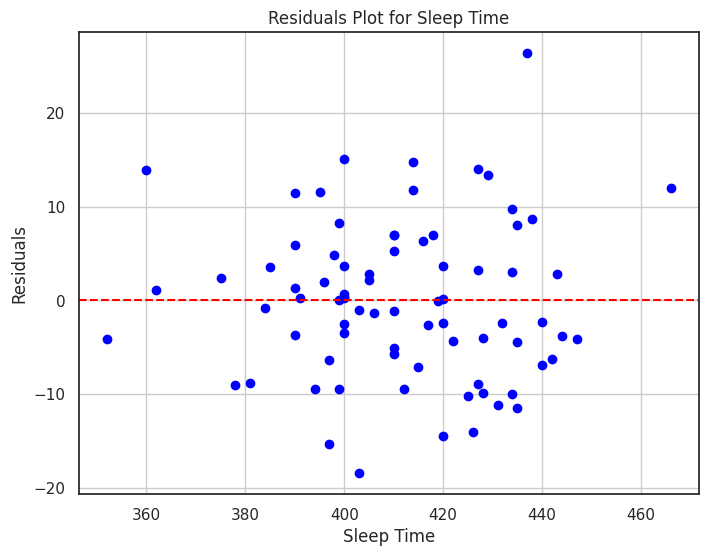

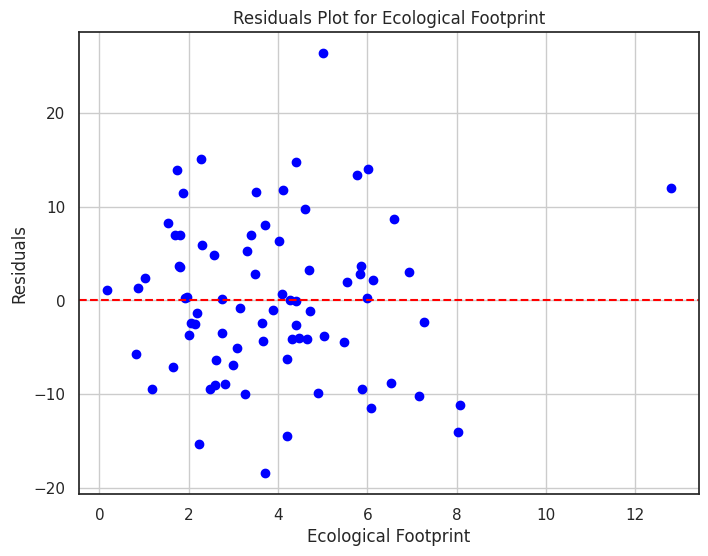

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Load data from Excel file
df = pd.read_excel('Вих Дані.xlsx')

# Drop the "Country" column
X = df.drop(columns=['Country', 'GDP per person employed by hour (C 2017 PPP $)'])

# Convert Y to numeric
y = pd.to_numeric(df['GDP per person employed by hour (C 2017 PPP $)'], errors='coerce')

# Remove NaN values
X = X.dropna()
y = y[X.index]

# Add constant to predictor
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X)
result = model.fit()

# Calculate residuals
residuals = result.resid

# Plot residuals for each predictor
for column in X.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(X[column], residuals, color='blue')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f"Residuals Plot for {column}")
    plt.xlabel(column)
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

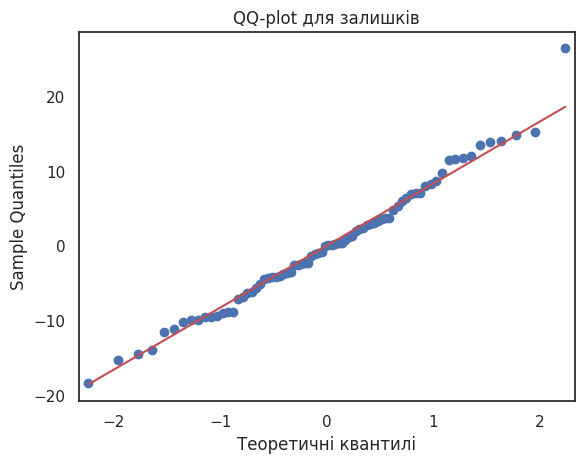

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats

df = pd.read_excel('Вих Дані.xlsx')
X = df.drop(columns=['Country', 'GDP per person employed by hour (C 2017 PPP $)'])

# Перетворення Y на числовий формат
y = pd.to_numeric(df['GDP per person employed by hour (C 2017 PPP $)'], errors='coerce')

# Додавання константи до предиктора
X = sm.add_constant(X)

# модель OLS
model = sm.OLS(y, X)
result = model.fit()

# Розрахунок залишків
residuals = result.resid

# QQ-plot
sm.qqplot(residuals, line='s')
plt.title('QQ-plot для залишків')
plt.xlabel('Теоретичні квантилі')
plt.show()

In [ ]:
# Отримання індексів викидів
outlier_residuals = result.get_influence().resid_studentized_external > 2  # Визначення викидів за критерієм

# Отримання значень залежної змінної y для викидів
outlier_y_values = df.loc[outlier_residuals, 'GDP per person employed by hour (C 2017 PPP $)']

# Виведення відповідних значень y
print("Значення y, що відповідають викидам:")
print(outlier_y_values)

Значення y, що відповідають викидам:
36    120.684295
Name: GDP per person employed by hour (C 2017 PPP $), dtype: float64


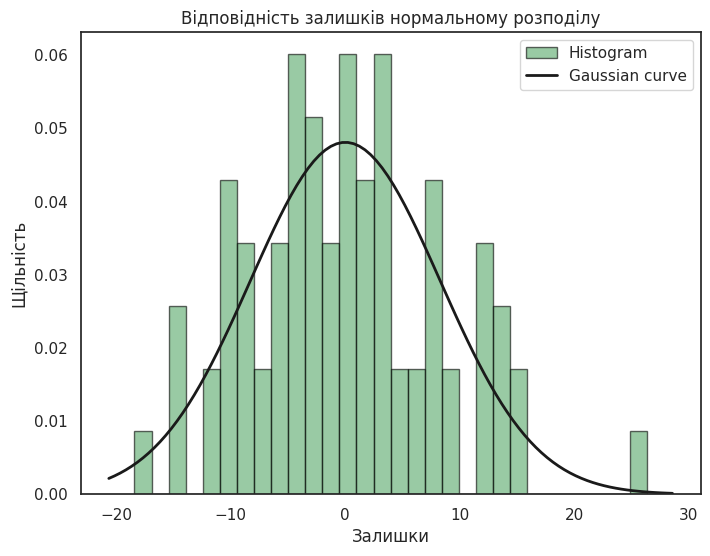

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g', edgecolor='black', label='Histogram')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(residuals), np.std(residuals))
plt.plot(x, p, 'k', linewidth=2, label='Gaussian curve')

plt.title('Відповідність залишків нормальному розподілу')
plt.xlabel('Залишки')
plt.ylabel('Щільність')
plt.legend()
plt.show()

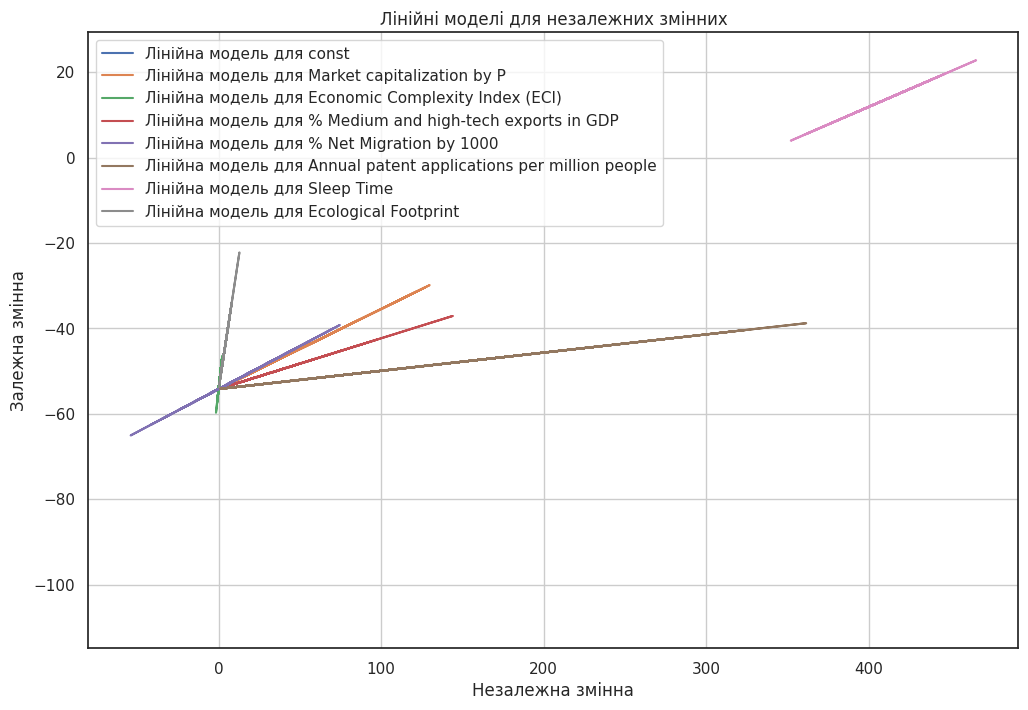

In [ ]:
import matplotlib.pyplot as plt

# Побудова моделі
model_fit = model.fit()

# Отримання коефіцієнтів регресії
coefficients = model_fit.params

# Отримання назв незалежних змінних
independent_variables = X.columns

# Побудова ліній для кожної незалежної змінної
plt.figure(figsize=(12, 8))

for i, variable in enumerate(independent_variables):
    slope = coefficients[variable]
    constant = coefficients['const']
    X_values = X[variable]
    predicted_Y = slope * X_values + constant
    plt.plot(X_values, predicted_Y, label=f'Лінійна модель для {variable}')

# Додавання легенди та маркера осей
plt.legend()
plt.xlabel('Незалежна змінна')
plt.ylabel('Залежна змінна')
plt.title('Лінійні моделі для незалежних змінних')
plt.grid(True)
plt.show()

In [ ]:
# Побудова моделі
model_fit = model.fit()

# Отримання коефіцієнтів регресії
coefficients = model_fit.params

# Виведення коефіцієнтів регресії
print("Коефіцієнти регресії:")
for variable, coefficient in coefficients.items():
    print(f"{variable}: {coefficient}")

Коефіцієнти регресії:
const: -54.1834477247279
Market capitalization by P: 0.187457997080972
Economic Complexity Index (ECI): 3.435605987244709
% Medium and high-tech exports in GDP: 0.1188306949547254
% Net Migration by 1000: 0.20110823013367798
Annual patent applications per million people: 0.0426436926061561
Sleep Time: 0.16529406549094944
Ecological Footprint: 2.502285623226534


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

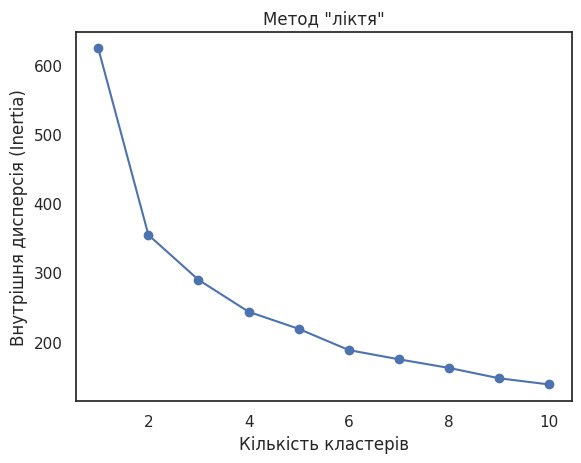

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Зчитуємо дані з файлу Excel
data = pd.read_excel('Вих Дані.xlsx')

# Виключаємо стовбець "Country"
data_for_clustering = data.drop(columns=['Country'])

# Стандартизуємо дані
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# Створюємо пустий список для збереження значень внутрішньої дисперсії
inertia = []

# Пробуємо різні кількості кластерів
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Побудова графіка методу "ліктя"
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Кількість кластерів')
plt.ylabel('Внутрішня дисперсія (Inertia)')
plt.title('Метод "ліктя"')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

linkage_matrix = linkage(scaled_data, method='ward')

# Визначаємо оптимальну кількість кластерів
max_d = 10  # максимальна відстань між кластерами
clusters = fcluster(linkage_matrix, max_d, criterion='distance')

num_clusters = len(np.unique(clusters))
print("Оптимальна кількість кластерів:", num_clusters)

Оптимальна кількість кластерів: 4


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.drop(columns=['Country']))

num_clusters = 4
# Побудова моделі k-means з використанням попередньої стандартизації
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(scaled_data)

# Додавання міток кластерів до даних
data_with_clusters = data.assign(Cluster=kmeans.labels_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


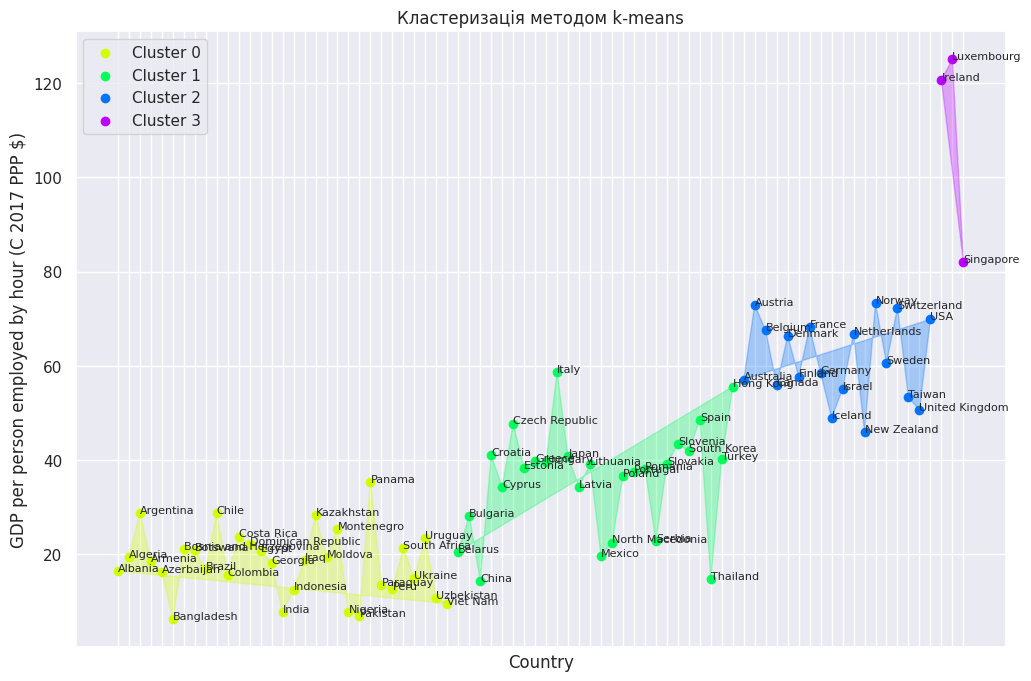

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Встановлення стилю Seaborn
sns.set_style("darkgrid")

# Створення кольорової палітри для кластерів
palette = sns.color_palette("hsv", num_clusters)

# Побудова графіку
plt.figure(figsize=(12, 8))
for cluster_num in range(num_clusters):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_num]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], color=palette[cluster_num], label=f'Cluster {cluster_num}')

    # Додавання позначок "Country" до кожного кластера зі зменшеним розміром шрифту
    for i, txt in enumerate(cluster_data['Country']):
        plt.annotate(txt, (cluster_data.iloc[i, 0], cluster_data.iloc[i, 1]), fontsize=8)

    # Зазначення кожного кластера зонами
    hull = plt.fill(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], color=palette[cluster_num], alpha=0.3, closed=True)

plt.title('Кластеризація методом k-means')
plt.xlabel(data_with_clusters.columns[0])
plt.ylabel(data_with_clusters.columns[1])

# Відключення показу позначок на осі x
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Ініціалізуємо PCA зі збереженням 80% дисперсії
pca = PCA(n_components=0.9)

# Застосовуємо PCA до даних
pca.fit(data_with_clusters.drop(columns=['Country', 'Cluster']))

num_components = pca.n_components_
print(f'Кількість компонент для пояснення мінімум 90% дисперсії: {num_components}')

Кількість компонент для пояснення мінімум 90% дисперсії: 2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


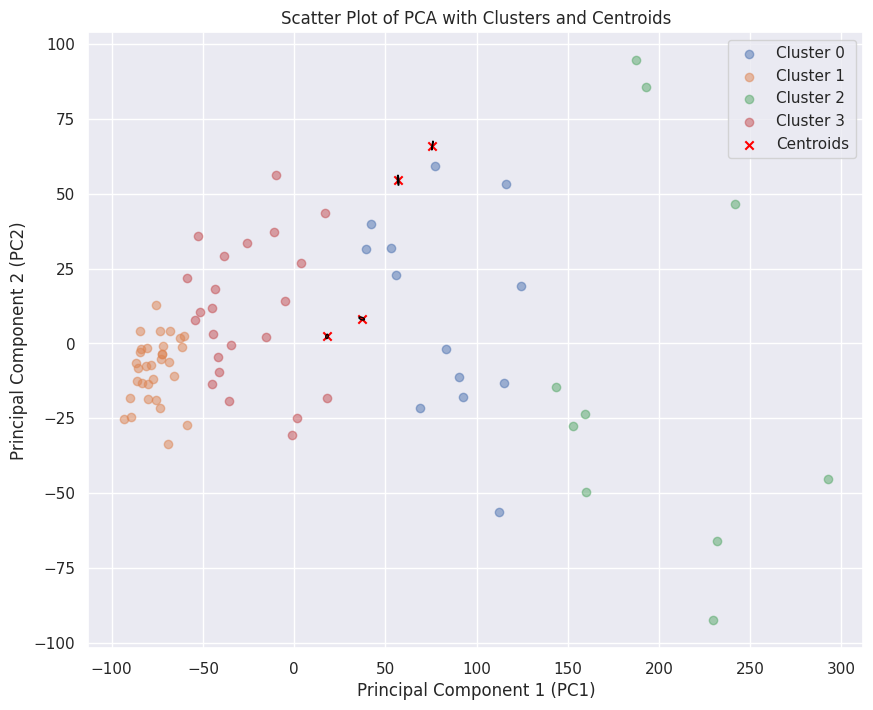

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Завантаження даних
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country"
data_without_country = data.drop(columns=["Country"])

# Виконуємо PCA з двома компонентами
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_without_country)

# Кластеризація методом к-середніх на 4 кластери
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_without_country)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Вираховуємо матрицю коваріації кожного кластера
covariances = []
for cluster in range(4):
    cluster_data = data_without_country[labels == cluster]
    covariance_matrix = np.cov(cluster_data.T)
    covariances.append(covariance_matrix)

# Створення DataFrame з головними компонентами та мітками кластерів
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
principal_df['Cluster'] = labels

# Графік розсіювання з відображенням кластерів та центрів кластерів
plt.figure(figsize=(10, 8))
for cluster in range(4):
    cluster_data = principal_df[principal_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster}', alpha=0.5)

# Відображення центроїдів
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', color='red', label='Centroids')

for cluster, covariance in enumerate(covariances):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))  # Використовуємо перші два значення eigenvectors
    width, height = 2 * np.sqrt(2) * np.sqrt(eigenvalues[:2])
    ellipse = Ellipse(xy=centroids[cluster], width=width, height=height, angle=angle, edgecolor='black', facecolor='none')
    plt.gca().add_patch(ellipse)


plt.title('Scatter Plot of PCA with Clusters and Centroids')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True)
plt.show()

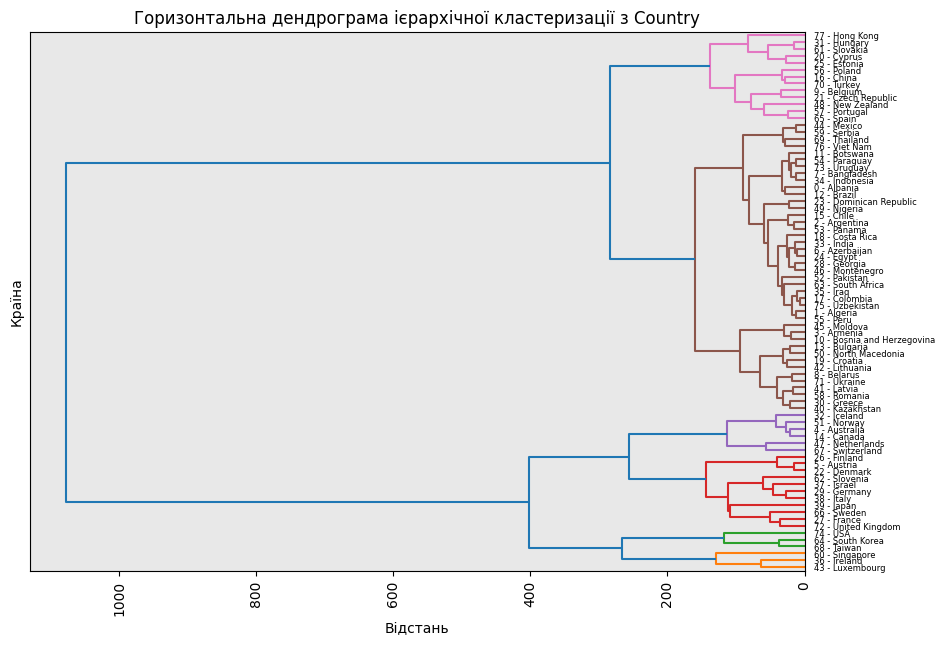

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Зчитуємо дані з Excel-файлу
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country", якщо він присутній
data_without_country = data.drop(columns=["Country"])

# Додаємо стовпець "Country" до відображення кластеризації
data_with_country = data.copy()

# Стандартизація даних
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_without_country)

# Виконуємо ієрархічну кластеризацію методом к-середніх
num_clusters = 4
model = AgglomerativeClustering(n_clusters=num_clusters, linkage='ward')
cluster_labels = model.fit_predict(data_without_country)

# Побудова дендрограми з використанням індексів даних
linked = linkage(data_without_country, 'ward')
# Створення списку міток у потрібному форматі
labels = ["{} - {}".format(idx, country) for idx, country in zip(data.index, data_with_country['Country'])]

# Побудова дендрограми з використанням створеного списку міток
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='left',  # Зміна орієнтації на горизонтальну
           labels=labels,  # Використовуємо список міток у потрібному форматі
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=250)

plt.title('Горизонтальна дендрограма ієрархічної кластеризації з Country')
plt.xlabel('Відстань')
plt.ylabel('Країна')
plt.xticks(rotation=90)  # Повернення міток на горизонтальний вигляд

# Додати фон
plt.axhspan(0, 1000, color='lightgrey', alpha=0.5)

# Змінити кольори кластерів
for i, d in zip(range(1, len(linked)+1), linked[:, 2]):
    if d < 450:
        plt.axvline(x=d, color='c', linestyle='')

# Зберегти графік у форматі PDF
plt.savefig('dendrogram.pdf')

plt.show()

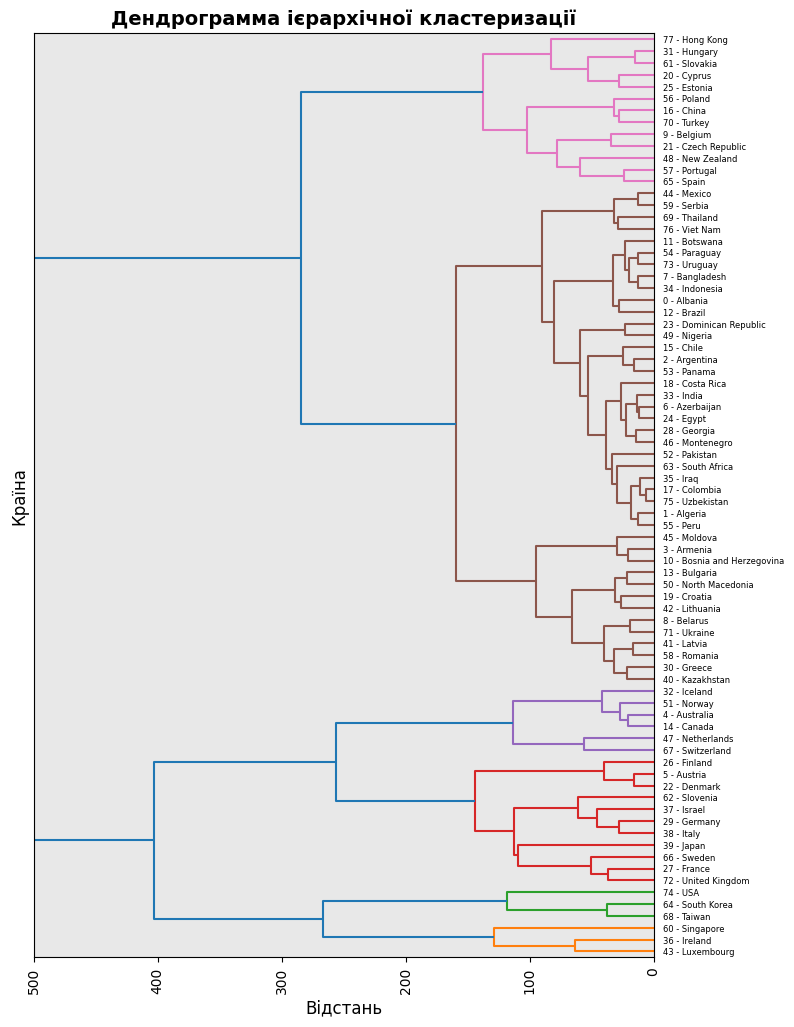

In [ ]:
plt.figure(figsize=(8, 12))
dendrogram(linked,
           orientation='left',  # Зміна орієнтації на горизонтальну
           labels=labels,  # Використовуємо список міток у потрібному форматі
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=250)

plt.title('Дендрограмма ієрархічної кластеризації', fontdict={'fontsize': 14, 'fontweight': 'bold'})  # Змінити шрифт заголовку
plt.xlabel('Відстань', fontdict={'fontsize': 12})  # Змінити шрифт назви осі X
plt.ylabel('Країна', fontdict={'fontsize': 12})  # Змінити шрифт назви осі Y
plt.xticks(rotation=90)  # Повернення міток на горизонтальний вигляд

# Змінити масштаб для проміжку відстаней 500-1000
plt.xlim(500, 0)

# Додати фон
plt.axhspan(0, 1000, color='lightgrey', alpha=0.5)

# Змінити кольори кластерів
for i, d in zip(range(1, len(linked)+1), linked[:, 2]):
    if 200 < d < 450:
        plt.axvline(x=d, color='c', linestyle='')

# Зберегти графік у форматі PDF
plt.savefig('dendrogram1.pdf')

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

# Зчитуємо дані з Excel-файлу
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country", якщо він присутній
data_without_country = data.drop(columns=["Country"])

# Отримуємо список країн
countries = data['Country'].values

# Створюємо матрицю відстаней на основі ієрархічної кластеризації
linked = linkage(data_without_country, 'ward')
distance_matrix = squareform(pdist(data_without_country, metric='euclidean'))

# Знаходимо індекс України в списку країн
ukraine_index = data[data['Country'] == 'Ukraine'].index[0]

# Отримуємо відстані від України до всіх інших країн
distances_to_ukraine = distance_matrix[ukraine_index]

# Знаходимо індекси 10 найменших відстаней (окрім самої України)
closest_indices = np.argsort(distances_to_ukraine)[1:21]

# Отримуємо назви країн з цими індексами та відповідні відстані
closest_countries = [(countries[i], distances_to_ukraine[i]) for i in closest_indices]

# Перетворюємо у таблицю для зручності
closest_countries_df = pd.DataFrame(closest_countries, columns=['Country', 'Distance'])

print(closest_countries_df)

       Country   Distance
0      Belarus  19.048633
1   Kazakhstan  21.046873
2      Georgia  23.953753
3       Greece  26.455159
4       Brazil  28.148044
5     Bulgaria  30.201856
6      Romania  31.062886
7       Serbia  31.720072
8       Latvia  32.545902
9   Montenegro  33.243833
10  Azerbaijan  33.267601
11     Armenia  35.043079
12    Portugal  36.366708
13   Argentina  36.759027
14       India  36.785132
15       Egypt  39.298735
16   Indonesia  39.686735
17     Croatia  41.061908
18      Panama  41.291860
19       Chile  41.571139


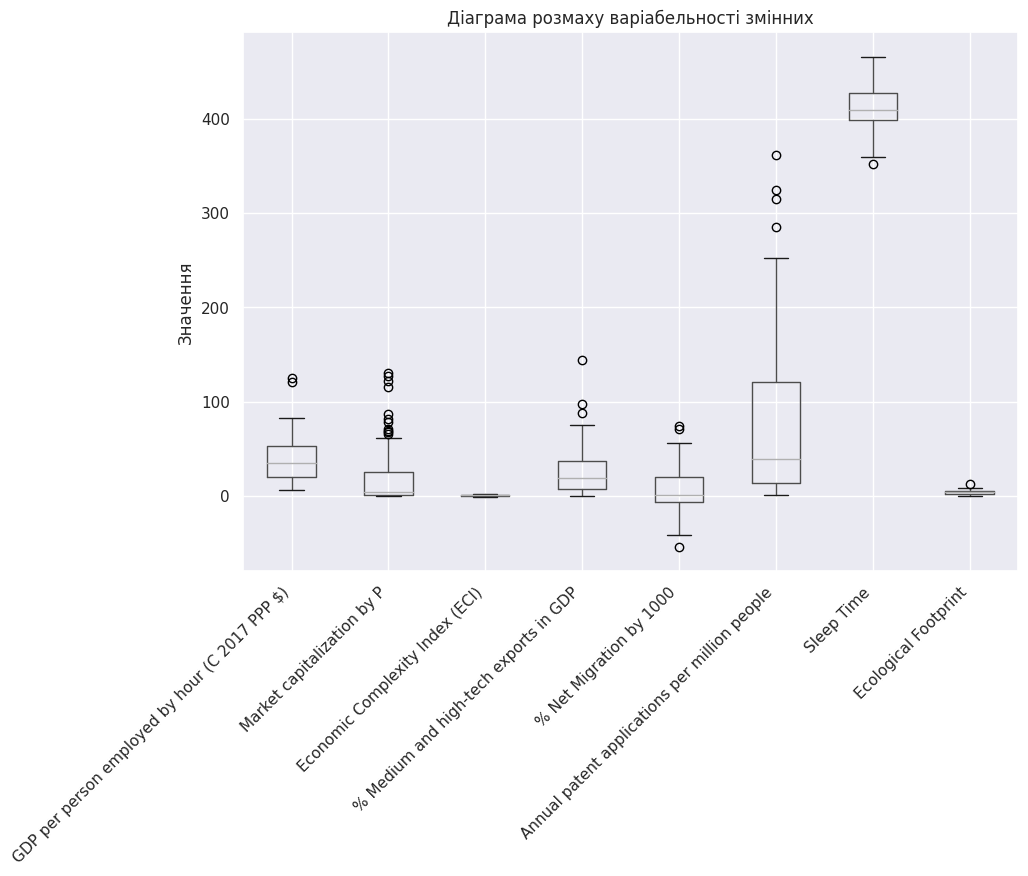

In [ ]:
plt.figure(figsize=(10, 7))
data_without_country.boxplot()
plt.title('Діаграма розмаху варіабельності змінних')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Значення')
plt.show()

In [ ]:
# Знаходження першого та третього квартилю
Q1 = data_without_country.quantile(0.25)
Q3 = data_without_country.quantile(0.75)

# Обчислення міжквартильного діапазону
IQR = Q3 - Q1

# Знаходження викидів за межами міжквартильного діапазону для кожної змінної
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = (data_without_country < lower_bound) | (data_without_country > upper_bound)

# Виведення викидів за межами розмаху для кожної змінної
print("Викиди за межами розмаху:")
for column in outliers.columns:
    print(f"Змінна '{column}':")
    print(outliers[outliers[column]].head(10))
    print()

Викиди за межами розмаху:
Змінна 'GDP per person employed by hour (C 2017 PPP $)':
    GDP per person employed by hour (C 2017 PPP $)  \
36                                            True   
43                                            True   

    Market capitalization by P  Economic Complexity Index (ECI)  \
36                        True                            False   
43                        True                            False   

    % Medium and high-tech exports in GDP  % Net Migration by 1000  \
36                                   True                     True   
43                                   True                     True   

    Annual patent applications per million people  Sleep Time  \
36                                          False       False   
43                                          False       False   

    Ecological Footprint  
36                 False  
43                  True  

Змінна 'Market capitalization by P':
    GDP per person employe

In [ ]:
# Додаємо стовпець з мітками кластерів до даних
data_with_clusters = data_without_country.copy()
data_with_clusters['Cluster'] = cluster_labels

# Обчислюємо середні значення кожного показника для кожного кластера
cluster_means = data_with_clusters.groupby('Cluster').mean()

# Виводимо середні значення кожного показника для кожного кластера
print("Середні значення кожного показника для кожного кластера:")
print(cluster_means)

Середні значення кожного показника для кожного кластера:
         GDP per person employed by hour (C 2017 PPP $)  \
Cluster                                                   
0                                             82.155913   
1                                             21.047288   
2                                             59.238235   
3                                             41.980601   

         Market capitalization by P  Economic Complexity Index (ECI)  \
Cluster                                                                
0                         93.083953                         1.710000   
1                          2.303027                         0.055952   
2                         47.735835                         1.308824   
3                         13.099990                         1.046154   

         % Medium and high-tech exports in GDP  % Net Migration by 1000  \
Cluster                                                                   
0    

In [ ]:
# Додаємо мітки кластерів до даних
data_with_country['Cluster'] = cluster_labels

# Групуємо дані за кластерними мітками та виводимо унікальні значення Country для кожного кластеру
for cluster_num in range(num_clusters):
    print(f"Кластер {cluster_num + 1}:")
    countries_in_cluster = data_with_country[data_with_country['Cluster'] == cluster_num]['Country'].unique()
    print(", ".join(countries_in_cluster))
    print()

Кластер 1:
Ireland, Luxembourg, Singapore, South Korea, Taiwan, USA

Кластер 2:
Albania, Algeria, Argentina, Armenia, Azerbaijan, Bangladesh, Belarus, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Chile, Colombia, Costa Rica, Croatia, Dominican Republic, Egypt, Georgia, Greece, India, Indonesia, Iraq, Kazakhstan, Latvia, Lithuania, Mexico, Moldova, Montenegro, Nigeria, North Macedonia, Pakistan, Panama, Paraguay, Peru, Romania, Serbia, South Africa, Thailand, Ukraine, Uruguay, Uzbekistan, Viet Nam

Кластер 3:
Australia, Austria, Canada, Denmark, Finland, France, Germany, Iceland, Israel, Italy, Japan, Netherlands, Norway, Slovenia, Sweden, Switzerland, United Kingdom

Кластер 4:
Belgium, China, Cyprus, Czech Republic, Estonia, Hungary, New Zealand, Poland, Portugal, Slovakia, Spain, Turkey, Hong Kong



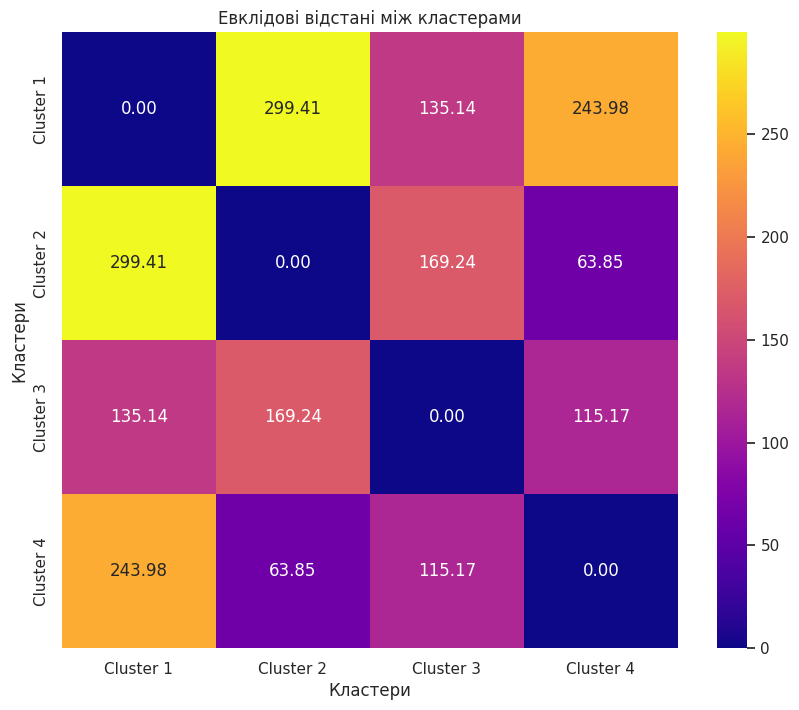

In [ ]:
import seaborn as sns
import numpy as np

# Обчислюємо матрицю відстаней між кластерами
distance_matrix = np.zeros((num_clusters, num_clusters))
for i in range(num_clusters):
    for j in range(num_clusters):
        # Обчислення евклідової відстані між центрами кластерів
        center_i = data_without_country[cluster_labels == i].mean(axis=0)
        center_j = data_without_country[cluster_labels == j].mean(axis=0)
        distance_matrix[i, j] = np.linalg.norm(center_i - center_j)

# Відображення матриці відстаней як теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=True, cmap='plasma', fmt=".2f", square=True,
            xticklabels=[f"Cluster {i+1}" for i in range(num_clusters)],
            yticklabels=[f"Cluster {i+1}" for i in range(num_clusters)])
plt.title('Евклідові відстані між кластерами')
plt.xlabel('Кластери')
plt.ylabel('Кластери')
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Створюємо пустий рядок для збереження результатів
results_str = ""

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Додаємо результати до рядка
    results_str += f"{column}\t{f_statistic}\t{len(groups) - 1}\t{p_value}\t{len(data_without_country) - len(groups)}\n"

# Виводимо результати
print("Variable\tBetween SS\tdf\tWithin SS\tdf\tF signif.\tp")
print(results_str)

Variable	Between SS	df	Within SS	df	F signif.	p
GDP per person employed by hour (C 2017 PPP $)	61.39439076848266	3	4.8988899823358014e-20	74
Market capitalization by P	51.899818705721124	3	3.6126676509876835e-18	74
Economic Complexity Index (ECI)	28.933746427676336	3	1.7405888102105176e-12	74
% Medium and high-tech exports in GDP	13.352383339135999	3	4.698281364875859e-07	74
% Net Migration by 1000	32.27153950784669	3	1.9058043967524233e-13	74
Annual patent applications per million people	198.98601796030118	3	2.455240959475992e-35	74
Sleep Time	5.694030808648362	3	0.0014553502089948661	74
Ecological Footprint	16.436189116684226	3	2.7864100727162892e-08	74



In [ ]:
from scipy.stats import f_oneway

# Створюємо порожні списки для збереження результатів
between_SS_values = []
within_SS_values = []

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Додаємо значення Between SS та Within SS до відповідних списків
    between_SS_values.append(f_statistic)
    within_SS_values.append(p_value)

# Виводимо значення міжгрупової та внутрішньогрупової дисперсій для кожної ознаки
print("Variable\tBetween Group Variance\tWithin Group Variance")
for i, column in enumerate(data_without_country.columns):
    print(f"{column}\t{between_SS_values[i]:.3f}\t{within_SS_values[i]}")

Variable	Between Group Variance	Within Group Variance
GDP per person employed by hour (C 2017 PPP $)	61.394	4.8988899823358014e-20
Market capitalization by P	51.900	3.6126676509876835e-18
Economic Complexity Index (ECI)	28.934	1.7405888102105176e-12
% Medium and high-tech exports in GDP	13.352	4.698281364875859e-07
% Net Migration by 1000	32.272	1.9058043967524233e-13
Annual patent applications per million people	198.986	2.455240959475992e-35
Sleep Time	5.694	0.0014553502089948661
Ecological Footprint	16.436	2.7864100727162892e-08


In [ ]:
from scipy.stats import f_oneway

# Створюємо пустий словник для збереження результатів
results = {}

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Зберігаємо результати в словнику
    results[column] = {'F statistic': f_statistic, 'p-value': p_value}

# Виводимо результати для кожного показника
for column, result in results.items():
    print(f"Results for {column}:")
    print("F statistic:", result['F statistic'])
    print("p-value:", result['p-value'])
    print()

Results for GDP per person employed by hour (C 2017 PPP $):
F statistic: 61.39439076848266
p-value: 4.8988899823358014e-20

Results for Market capitalization by P:
F statistic: 51.899818705721124
p-value: 3.6126676509876835e-18

Results for Economic Complexity Index (ECI):
F statistic: 28.933746427676336
p-value: 1.7405888102105176e-12

Results for % Medium and high-tech exports in GDP:
F statistic: 13.352383339135999
p-value: 4.698281364875859e-07

Results for % Net Migration by 1000:
F statistic: 32.27153950784669
p-value: 1.9058043967524233e-13

Results for Annual patent applications per million people:
F statistic: 198.98601796030118
p-value: 2.455240959475992e-35

Results for Sleep Time:
F statistic: 5.694030808648362
p-value: 0.0014553502089948661

Results for Ecological Footprint:
F statistic: 16.436189116684226
p-value: 2.7864100727162892e-08



In [ ]:
from tabulate import tabulate

data = {
    "Variables": ["GDP per person employed by hour (C 2017 PPP $)", "Market capitalization by P",
                  "Economic Complexity Index (ECI)", "% Medium and high-tech exports in GDP",
                  "% Net Migration by 1000", "Annual patent applications per million people",
                  "Sleep Time", "Ecological Footprint"],
    "Between_SS": [61.394, 51.899, 28.933, 13.352, 32.271, 198.986, 5.694, 16.436],
    "df_between": [3, 3, 3, 3, 3, 3, 3, 3],
    "Within_SS": [4.898e-20, 3.612e-18, 1.740e-12, 4.698e-07, 1.905e-13, 2.455e-35, 0.0014, 2.786e-08],
    "df_within": [74, 74, 74, 74, 74, 74, 74, 74],
    "F_statistic": [61.394, 51.899, 28.933, 13.352, 32.271, 198.986, 5.694, 16.436],
    "p_values": [4.898e-20, 3.612e-18, 1.740e-12, 4.698e-07, 1.905e-13, 2.455e-35, 0.0014, 2.786e-08]
}

headers = data.keys()
rows = zip(*data.values())

print(tabulate(rows, headers=headers))

Variables                                         Between_SS    df_between    Within_SS    df_within    F_statistic    p_values
----------------------------------------------  ------------  ------------  -----------  -----------  -------------  ----------
GDP per person employed by hour (C 2017 PPP $)        61.394             3    4.898e-20           74         61.394   4.898e-20
Market capitalization by P                            51.899             3    3.612e-18           74         51.899   3.612e-18
Economic Complexity Index (ECI)                       28.933             3    1.74e-12            74         28.933   1.74e-12
% Medium and high-tech exports in GDP                 13.352             3    4.698e-07           74         13.352   4.698e-07
% Net Migration by 1000                               32.271             3    1.905e-13           74         32.271   1.905e-13
Annual patent applications per million people        198.986             3    2.455e-35           74     

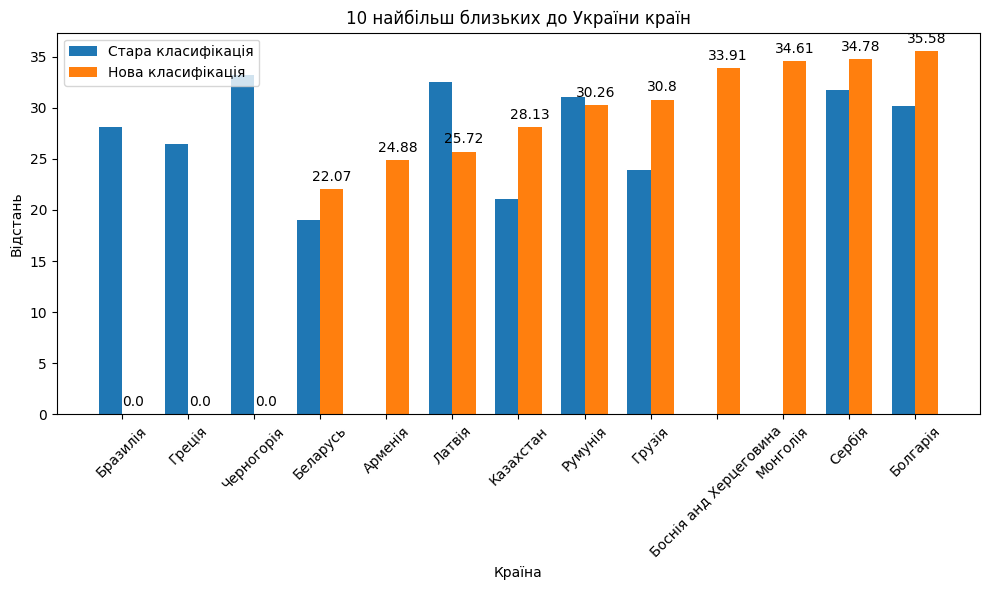

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Введення даних для старої та нової класифікацій
data_old = {
    'Країна': ['Беларусь', 'Казахстан', 'Грузія', 'Греція', 'Бразилія', 'Болгарія', 'Румунія', 'Сербія', 'Латвія', 'Черногорія'],
    'Стара класифікація': [19.04, 21.04, 23.95, 26.45, 28.14, 30.21, 31.06, 31.72, 32.54, 33.24]
}

data_new = {
    'Країна': ['Беларусь', 'Арменія', 'Латвія', 'Казахстан', 'Румунія', 'Грузія', 'Боснія анд Херцеговина', 'Монголія', 'Сербія', 'Болгарія'],
    'Нова класифікація': [22.07, 24.88, 25.72, 28.13, 30.26, 30.80, 33.91, 34.61, 34.78, 35.58]
}

# Створення DataFrames
df_old = pd.DataFrame(data_old)
df_new = pd.DataFrame(data_new)

# Об'єднання даних за стовпцем 'Країна'
df = pd.merge(df_old, df_new, on='Країна', how='outer')

# Перевірка на наявність пропущених значень і заповнення їх для коректної побудови графіка
df['Стара класифікація'] = df['Стара класифікація'].fillna(0)
df['Нова класифікація'] = df['Нова класифікація'].fillna(0)

# Сортування за "Новою класифікацією"
df = df.sort_values(by='Нова класифікація')

# Візуалізація
fig, ax = plt.subplots(figsize=(10, 6))

# Побудова стовпчастої діаграми
width = 0.35
x = np.arange(len(df['Країна']))

# Стовпчики для старої та нової класифікації
bars1 = ax.bar(x - width/2, df['Стара класифікація'], width, label='Стара класифікація')
bars2 = ax.bar(x + width/2, df['Нова класифікація'], width, label='Нова класифікація')

# Додавання міток відстані над стовпчиками для "Нової класифікації"
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom', fontsize=10)

# Настроювання графіка
ax.set_xlabel('Країна')
ax.set_ylabel('Відстань')
ax.set_title('10 найбільш близьких до України країн')
ax.set_xticks(x)
ax.set_xticklabels(df['Країна'], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

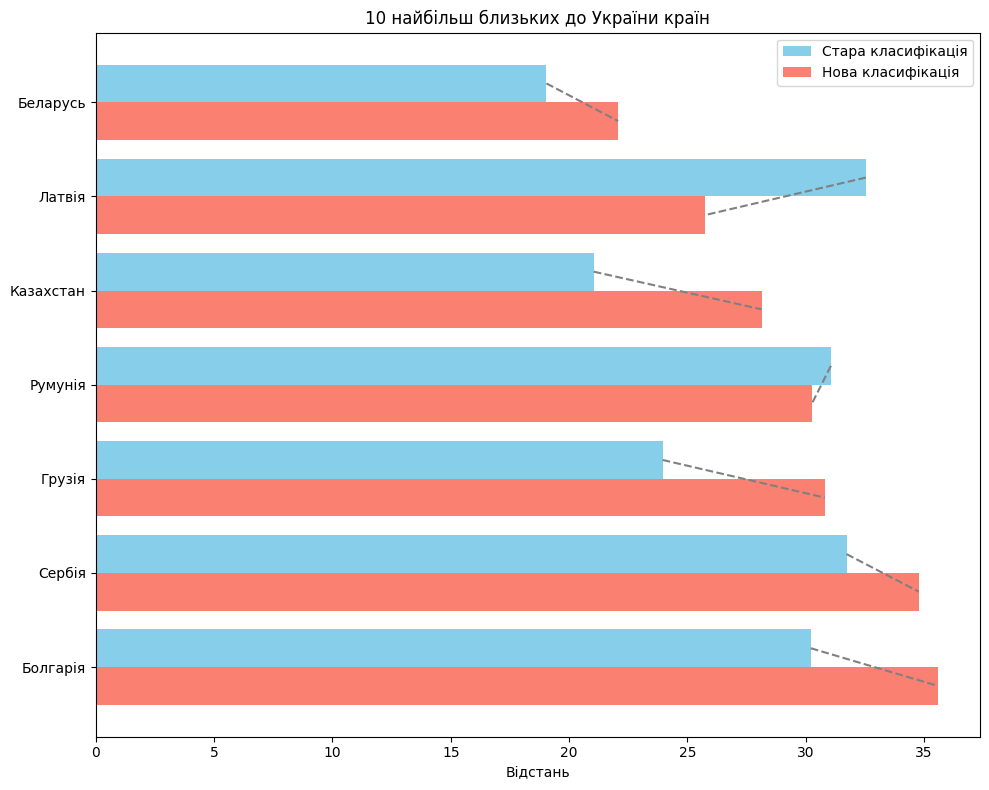

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Дані для старої та нової класифікацій
data_old = {
    'Країна': ['Беларусь', 'Казахстан', 'Грузія', 'Греція', 'Бразилія', 'Болгарія', 'Румунія', 'Сербія', 'Латвія', 'Черногорія'],
    'Стара класифікація': [19.04, 21.04, 23.95, 26.45, 28.14, 30.21, 31.06, 31.72, 32.54, 33.24]
}

data_new = {
    'Країна': ['Беларусь', 'Арменія', 'Латвія', 'Казахстан', 'Румунія', 'Грузія', 'Боснія анд Херцеговина', 'Монголія', 'Сербія', 'Болгарія'],
    'Нова класифікація': [22.07, 24.88, 25.72, 28.13, 30.26, 30.80, 33.91, 34.61, 34.78, 35.58]
}

# Створення DataFrames
df_old = pd.DataFrame(data_old)
df_new = pd.DataFrame(data_new)

# З'єднання даних по стовпцю "Країна"
df = pd.merge(df_old, df_new, on='Країна', how='inner')

# Сортування за "Новою класифікацією" для відповідного відображення
df = df.sort_values(by='Нова класифікація')

# Візуалізація
fig, ax = plt.subplots(figsize=(10, 8))

# Відступ для розміщення обох класифікацій
y = range(len(df['Країна']))

# Побудова стовпців для старої класифікації зліва
ax.barh(y, df['Стара класифікація'], color='skyblue', height=0.4, label='Стара класифікація', align='center')

# Побудова стовпців для нової класифікації справа
ax.barh([i + 0.4 for i in y], df['Нова класифікація'], color='salmon', height=0.4, label='Нова класифікація', align='center')

# Додавання ліній між стовпчиками для відображення зв'язку
for i, країна in enumerate(df['Країна']):
    ax.plot([df['Стара класифікація'].iloc[i], df['Нова класифікація'].iloc[i]], [i, i + 0.4], color='gray', linestyle='--')

# Настроювання осей та міток
ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(df['Країна'])
ax.set_xlabel('Відстань')
ax.set_title('10 найбільш близьких до України країн')
ax.legend()

plt.gca().invert_yaxis()  # Інвертуємо вісь Y для кращої читабельності
plt.tight_layout()
plt.show()

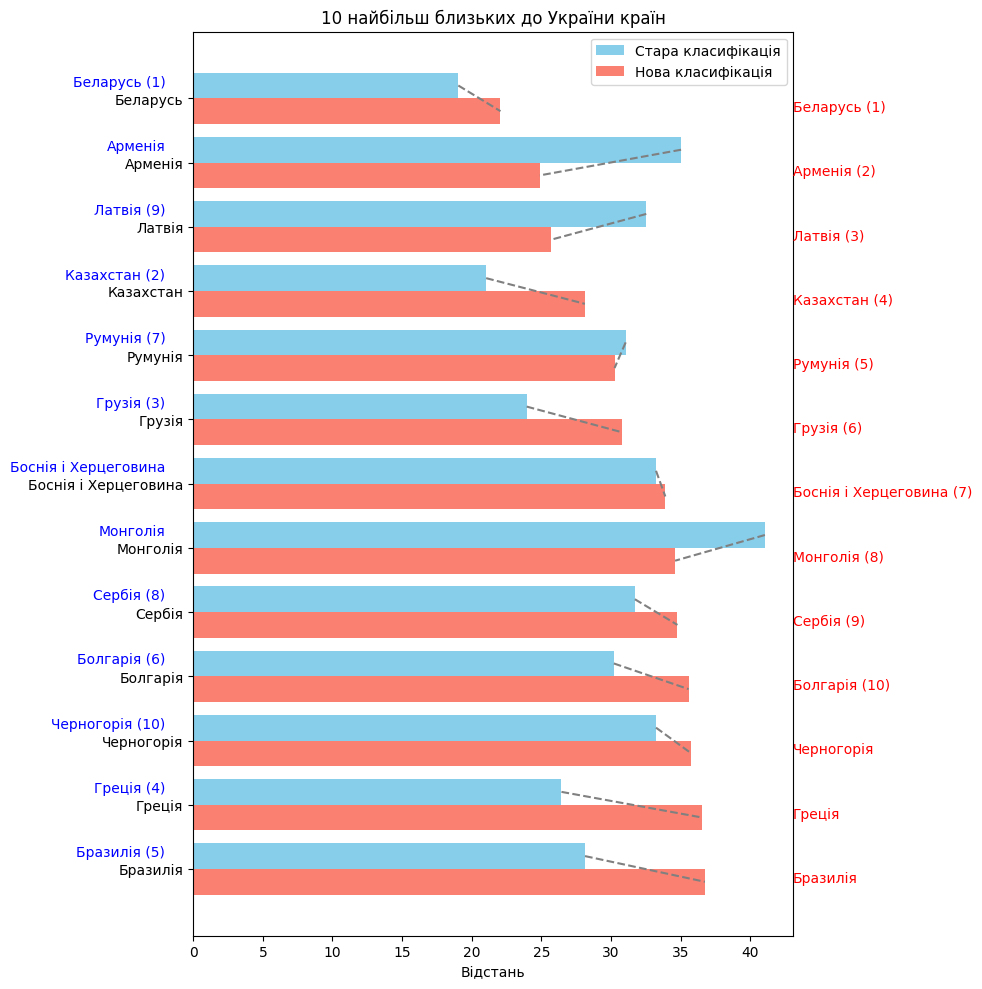

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Оновлені дані для старої та нової класифікацій з рейтингами
data_old = {
    'Країна': ['Беларусь', 'Казахстан', 'Грузія', 'Греція', 'Бразилія', 'Болгарія', 'Румунія', 'Сербія', 'Латвія', 'Черногорія', 'Боснія і Херцеговина', 'Монголія', 'Арменія'],
    'Стара класифікація': [19.04, 21.04, 23.95, 26.45, 28.14, 30.21, 31.06, 31.72, 32.54, 33.24, 33.24, 41.06, 35.04],
    'Рейтинг_стара': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

data_new = {
    'Країна': ['Беларусь', 'Арменія', 'Латвія', 'Казахстан', 'Румунія', 'Грузія', 'Боснія і Херцеговина', 'Монголія', 'Сербія', 'Болгарія', 'Греція', 'Бразилія', 'Черногорія'],
    'Нова класифікація': [22.07, 24.88, 25.72, 28.13, 30.26, 30.80, 33.91, 34.61, 34.78, 35.58, 36.57, 36.75, 35.77],
    'Рейтинг_нова': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

# Створення DataFrames
df_old = pd.DataFrame(data_old)
df_new = pd.DataFrame(data_new)

# З'єднання даних по стовпцю "Країна"
df = pd.merge(df_old, df_new, on='Країна', how='outer')

# Сортування за "Новою класифікацією" для відповідного відображення
df = df.sort_values(by='Нова класифікація')

# Візуалізація
fig, ax = plt.subplots(figsize=(10, 10))

# Відступ для розміщення обох класифікацій
y = range(len(df['Країна']))

# Побудова стовпців для старої класифікації зліва
ax.barh(y, df['Стара класифікація'], color='skyblue', height=0.4, label='Стара класифікація', align='center')

# Побудова стовпців для нової класифікації справа
ax.barh([i + 0.4 for i in y], df['Нова класифікація'], color='salmon', height=0.4, label='Нова класифікація', align='center')

# Додавання ліній між стовпчиками для відображення зв'язку
for i, країна in enumerate(df['Країна']):
    if pd.notna(df['Стара класифікація'].iloc[i]) and pd.notna(df['Нова класифікація'].iloc[i]):
        ax.plot([df['Стара класифікація'].iloc[i], df['Нова класифікація'].iloc[i]], [i, i + 0.4], color='gray', linestyle='--')

# Додавання рейтингу поруч з назвою країни
for i, (країна, рейтинг_стара, рейтинг_нова) in enumerate(zip(df['Країна'], df['Рейтинг_стара'], df['Рейтинг_нова'])):
    label_old = f"{країна} ({int(рейтинг_стара)})" if pd.notna(рейтинг_стара) else країна
    label_new = f"{країна} ({int(рейтинг_нова)})" if pd.notna(рейтинг_нова) else країна
    ax.text(-2, y[i], label_old, ha='right', color='blue', fontsize=10)
    ax.text(max(df['Стара класифікація'].max(), df['Нова класифікація'].max()) + 2, y[i] + 0.4, label_new, ha='left', color='red', fontsize=10)

# Настроювання осей та міток
ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(df['Країна'])
ax.set_xlabel('Відстань')
ax.set_title('10 найбільш близьких до України країн')
ax.legend()

plt.gca().invert_yaxis()  # Інвертуємо вісь Y для кращої читабельності
plt.tight_layout()
plt.show()


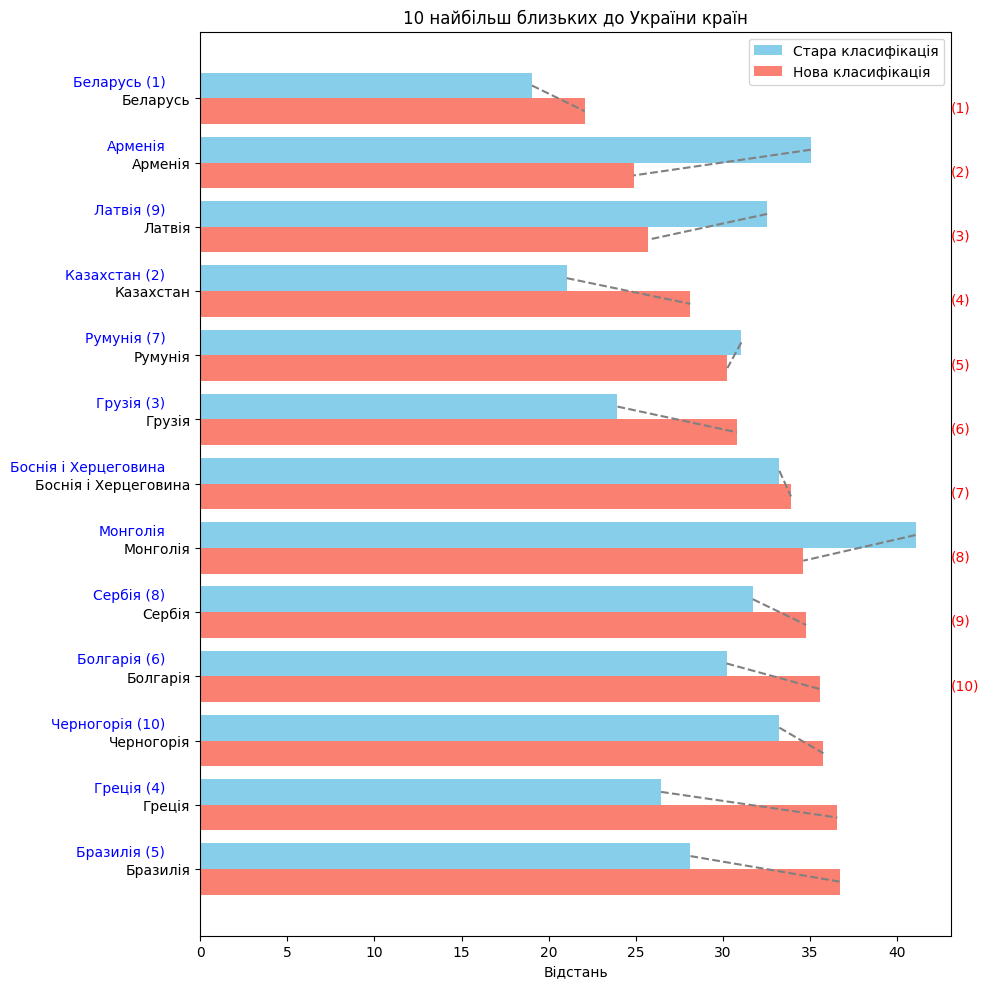

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Оновлені дані для старої та нової класифікацій з рейтингами
data_old = {
    'Країна': ['Беларусь', 'Казахстан', 'Грузія', 'Греція', 'Бразилія', 'Болгарія', 'Румунія', 'Сербія', 'Латвія', 'Черногорія', 'Боснія і Херцеговина', 'Монголія', 'Арменія'],
    'Стара класифікація': [19.04, 21.04, 23.95, 26.45, 28.14, 30.21, 31.06, 31.72, 32.54, 33.24, 33.24, 41.06, 35.04],
    'Рейтинг_стара': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

data_new = {
    'Країна': ['Беларусь', 'Арменія', 'Латвія', 'Казахстан', 'Румунія', 'Грузія', 'Боснія і Херцеговина', 'Монголія', 'Сербія', 'Болгарія', 'Греція', 'Бразилія', 'Черногорія'],
    'Нова класифікація': [22.07, 24.88, 25.72, 28.13, 30.26, 30.80, 33.91, 34.61, 34.78, 35.58, 36.57, 36.75, 35.77],
    'Рейтинг_нова': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

# Створення DataFrames
df_old = pd.DataFrame(data_old)
df_new = pd.DataFrame(data_new)

# З'єднання даних по стовпцю "Країна"
df = pd.merge(df_old, df_new, on='Країна', how='outer')

# Сортування за "Новою класифікацією" для відповідного відображення
df = df.sort_values(by='Нова класифікація')

# Візуалізація
fig, ax = plt.subplots(figsize=(10, 10))

# Відступ для розміщення обох класифікацій
y = range(len(df['Країна']))

# Побудова стовпців для старої класифікації зліва
ax.barh(y, df['Стара класифікація'], color='skyblue', height=0.4, label='Стара класифікація', align='center')

# Побудова стовпців для нової класифікації справа
ax.barh([i + 0.4 for i in y], df['Нова класифікація'], color='salmon', height=0.4, label='Нова класифікація', align='center')

# Додавання ліній між стовпчиками для відображення зв'язку
for i, країна in enumerate(df['Країна']):
    if pd.notna(df['Стара класифікація'].iloc[i]) and pd.notna(df['Нова класифікація'].iloc[i]):
        ax.plot([df['Стара класифікація'].iloc[i], df['Нова класифікація'].iloc[i]], [i, i + 0.4], color='gray', linestyle='--')

# Додавання рейтингу поруч з назвою країни
for i, (країна, рейтинг_стара, рейтинг_нова) in enumerate(zip(df['Країна'], df['Рейтинг_стара'], df['Рейтинг_нова'])):
    # Показуємо країну і рейтинг старої класифікації зліва
    label_old = f"{країна} ({int(рейтинг_стара)})" if pd.notna(рейтинг_стара) else країна
    ax.text(-2, y[i], label_old, ha='right', color='blue', fontsize=10)

    # Показуємо тільки рейтинг нової класифікації праворуч
    if pd.notna(рейтинг_нова):
        ax.text(max(df['Стара класифікація'].max(), df['Нова класифікація'].max()) + 2, y[i] + 0.4, f"({int(рейтинг_нова)})", ha='left', color='red', fontsize=10)

# Настроювання осей та міток
ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(df['Країна'])
ax.set_xlabel('Відстань')
ax.set_title('10 найбільш близьких до України країн')
ax.legend()

plt.gca().invert_yaxis()  # Інвертуємо вісь Y для кращої читабельності
plt.tight_layout()
plt.show()


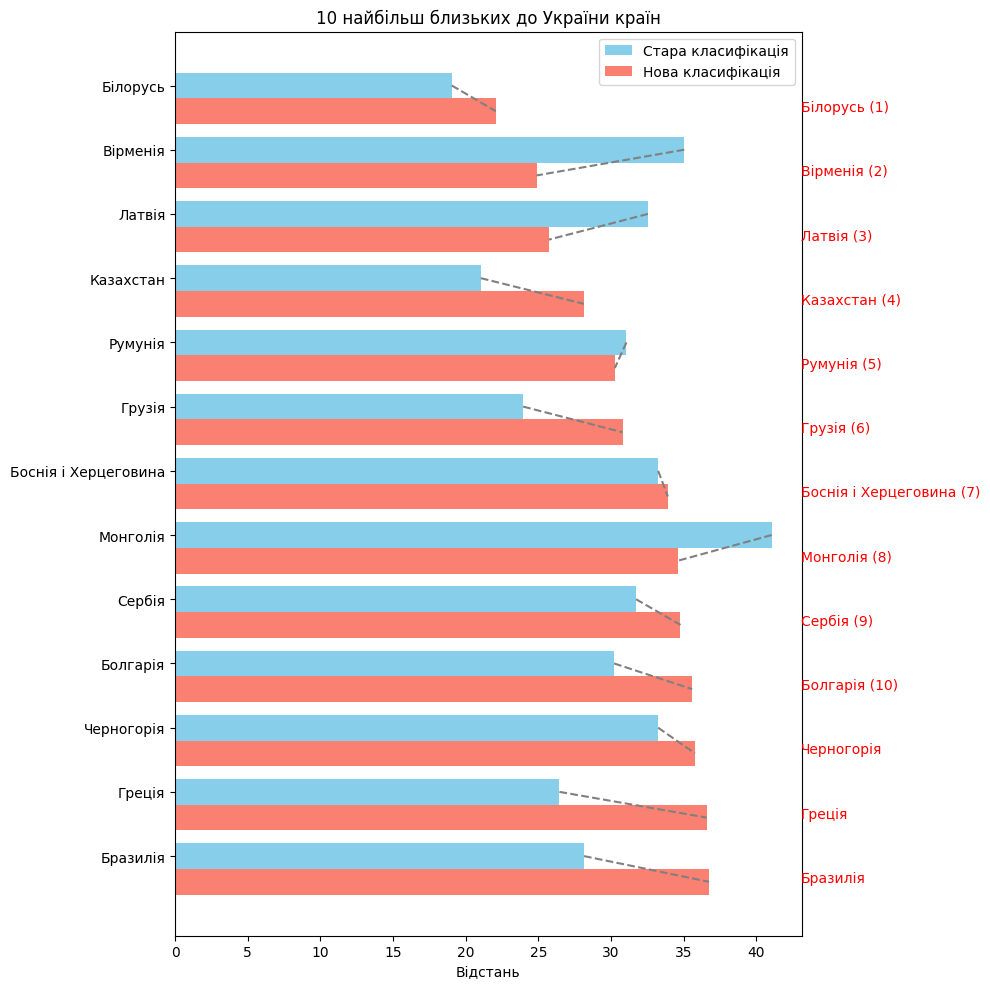

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Оновлені дані для старої та нової класифікацій з рейтингами
data_old = {
    'Країна': ['Білорусь', 'Казахстан', 'Грузія', 'Греція', 'Бразилія', 'Болгарія', 'Румунія', 'Сербія', 'Латвія', 'Черногорія', 'Боснія і Херцеговина', 'Монголія', 'Вірменія'],
    'Стара класифікація': [19.04, 21.04, 23.95, 26.45, 28.14, 30.21, 31.06, 31.72, 32.54, 33.24, 33.24, 41.06, 35.04],
    'Рейтинг_стара': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

data_new = {
    'Країна': ['Білорусь', 'Вірменія', 'Латвія', 'Казахстан', 'Румунія', 'Грузія', 'Боснія і Херцеговина', 'Монголія', 'Сербія', 'Болгарія', 'Греція', 'Бразилія', 'Черногорія'],
    'Нова класифікація': [22.07, 24.88, 25.72, 28.13, 30.26, 30.80, 33.91, 34.61, 34.78, 35.58, 36.57, 36.75, 35.77],
    'Рейтинг_нова': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None, None, None]
}

# Створення DataFrames
df_old = pd.DataFrame(data_old)
df_new = pd.DataFrame(data_new)

# З'єднання даних по стовпцю "Країна"
df = pd.merge(df_old, df_new, on='Країна', how='outer')

# Сортування за "Новою класифікацією" для відповідного відображення
df = df.sort_values(by='Нова класифікація')

# Візуалізація
fig, ax = plt.subplots(figsize=(10, 10))

# Відступ для розміщення обох класифікацій
y = range(len(df['Країна']))

# Побудова стовпців для старої класифікації зліва
ax.barh(y, df['Стара класифікація'], color='skyblue', height=0.4, label='Стара класифікація', align='center')

# Побудова стовпців для нової класифікації справа
ax.barh([i + 0.4 for i in y], df['Нова класифікація'], color='salmon', height=0.4, label='Нова класифікація', align='center')

# Додавання ліній між стовпчиками для відображення зв'язку
for i, країна in enumerate(df['Країна']):
    if pd.notna(df['Стара класифікація'].iloc[i]) and pd.notna(df['Нова класифікація'].iloc[i]):
        ax.plot([df['Стара класифікація'].iloc[i], df['Нова класифікація'].iloc[i]], [i, i + 0.4], color='gray', linestyle='--')

# Додавання рейтингу поруч з країною з нової класифікації праворуч
for i, (країна, рейтинг_нова) in enumerate(zip(df['Країна'], df['Рейтинг_нова'])):
    # Показуємо назву країни і рейтинг нової класифікації праворуч
    label_new = f"{країна} ({int(рейтинг_нова)})" if pd.notna(рейтинг_нова) else країна
    ax.text(max(df['Стара класифікація'].max(), df['Нова класифікація'].max()) + 2, i + 0.4, label_new, ha='left', color='red', fontsize=10)

# Настроювання осей та міток
ax.set_yticks([i for i in y])
ax.set_yticklabels(df['Країна'])
ax.set_xlabel('Відстань')
ax.set_title('10 найбільш близьких до України країн')
ax.legend()

plt.gca().invert_yaxis()  # Інвертуємо вісь Y для кращої читабельності
plt.tight_layout()
plt.show()
